Dataset Preparation

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/merged_city_sales_data.csv')

# Load and aggregate data at city/country level
def prepare_geographic_data(df):
    """
    Aggregate sales data at city/country level for market analysis
    """

    # Calculate key metrics per city
    city_metrics = df.groupby(['city', 'country_norm_mapped']).agg({
        'sales_amount_realistic': ['sum', 'mean', 'count'],
        'quantity_realistic': 'sum',
        'store_id': pd.Series.nunique,
        'product_id': pd.Series.nunique,
        'gdp_per_capita': 'first',
        'internet_usage_pct': 'first',
        'exchange_rate': 'first',
        'inflation_rate': 'first',
        'price_realistic': 'mean',
        'Population': 'first'  # ADDED: Population column
    }).round(2)

    # Flatten column names
    city_metrics.columns = ['_'.join(col).strip() for col in city_metrics.columns.values]
    city_metrics = city_metrics.reset_index()

    # Rename columns for clarity
    city_metrics = city_metrics.rename(columns={
        'sales_amount_realistic_sum': 'total_revenue',
        'sales_amount_realistic_mean': 'avg_transaction_value',
        'sales_amount_realistic_count': 'transaction_count',
        'quantity_realistic_sum': 'total_units_sold',
        'store_id_nunique': 'store_count',
        'product_id_nunique': 'product_variety'
    })

    # Calculate derived metrics
    city_metrics['revenue_per_store'] = city_metrics['total_revenue'] / city_metrics['store_count']
    city_metrics['units_per_transaction'] = city_metrics['total_units_sold'] / city_metrics['transaction_count']
    city_metrics['market_maturity'] = pd.cut(
        city_metrics['store_count'],
        bins=[0, 1, 3, 5, float('inf')],
        labels=['New', 'Developing', 'Established', 'Mature']
    )

    return city_metrics

# Prepare your data (assuming df is your dataframe)
city_data = prepare_geographic_data(df)
print(f"Analyzing {len(city_data)} cities across {city_data['country_norm_mapped'].nunique()} countries")
print("\nSample data:")
print(city_data.head())

Analyzing 47 cities across 19 countries

Sample data:
        city   country_norm_mapped  total_revenue  avg_transaction_value  \
0  Abu Dhabi  united arab emirates   7.999174e+07                5806.60   
1  Amsterdam           netherlands   9.281900e+07                6625.67   
2    Bangkok              thailand   1.467415e+08                3533.13   
3  Barcelona                 spain   8.026670e+07                5864.88   
4    Beijing                 china   9.435336e+07                3373.74   

   transaction_count  total_units_sold  store_count  product_variety  \
0              13776             74922            1               89   
1              14009             86173            1               89   
2              41533            140637            3               89   
3              13686             75104            1               89   
4              27967             90759            2               89   

   gdp_per_capita_first  internet_usage_pct_first  excha

1. Geospatial Clustering - Identify Similar Markets

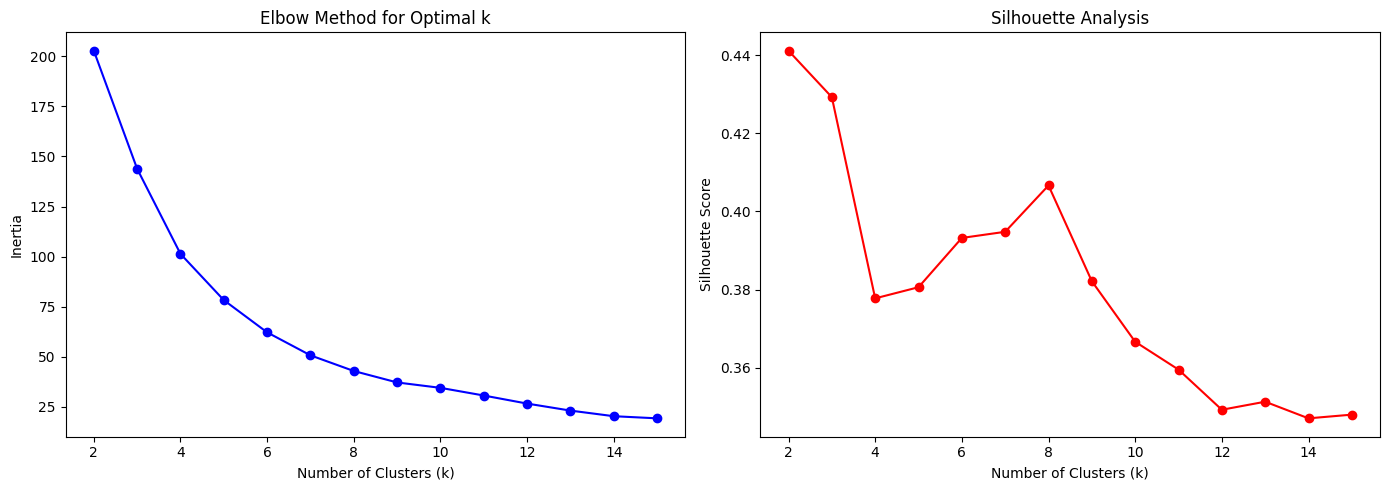

Optimal number of clusters: 2


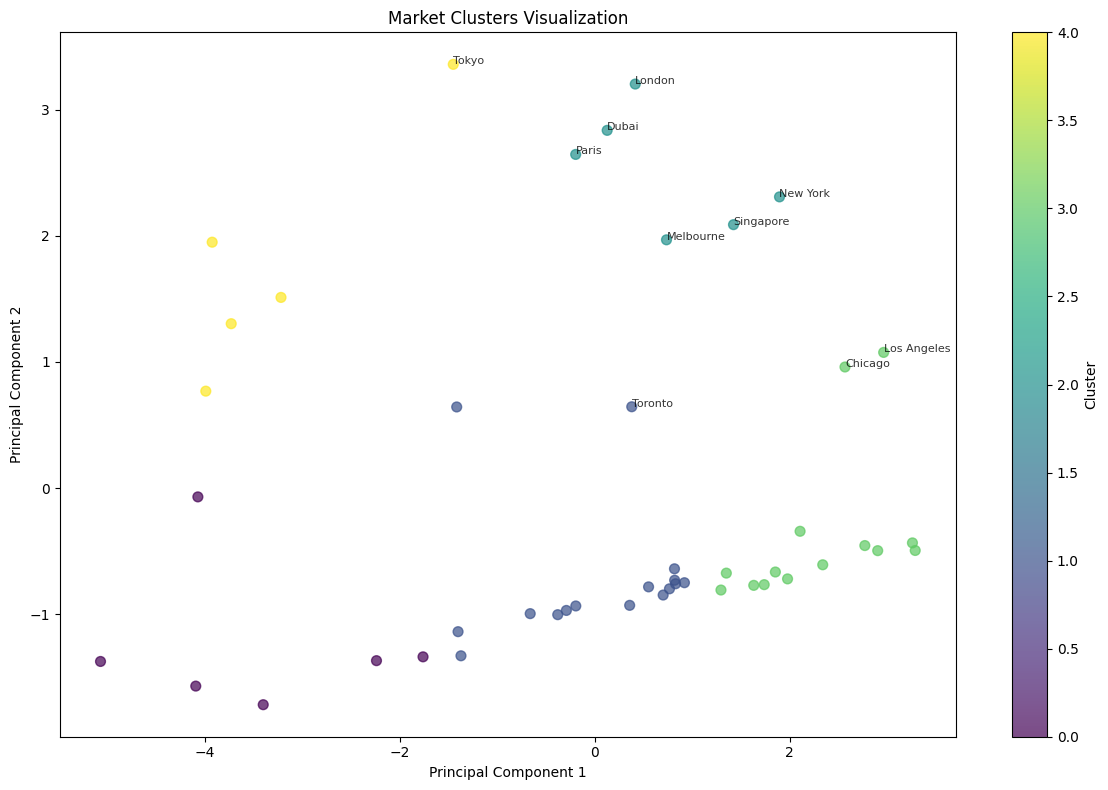


Cluster Profiles:
                num_cities  total_revenue  store_count  gdp_per_capita_first  \
kmeans_cluster                                                                 
0                        6   5.650191e+07         1.17              16900.84   
1                       16   1.006775e+08         1.12              41957.19   
2                        6   3.368973e+08         3.50              49058.61   
3                       14   1.600962e+08         1.14              60209.11   
4                        5   1.449370e+08         2.60              15422.11   

                internet_usage_pct_first  avg_transaction_value  \
kmeans_cluster                                                    
0                                  70.15                3608.04   
1                                  91.89                6544.93   
2                                  92.76                7046.38   
3                                  91.41               10061.98   
4                 

In [17]:
class GeographicMarketClustering:
    """
    Cluster cities based on market characteristics to identify similar markets
    """

    def __init__(self, n_clusters=5):
        self.n_clusters = n_clusters
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        self.pca = PCA(n_components=2)

    def prepare_features(self, city_data):
        """
        Select and scale features for clustering
        """
        features = [
            'gdp_per_capita_first',
            'internet_usage_pct_first',
            'store_count',
            'total_revenue',
            'avg_transaction_value',
            'product_variety',
            'revenue_per_store',
            'units_per_transaction',
            'Population_first'  # Corrected: Population column name
        ]

        # Handle missing values
        X = city_data[features].fillna(city_data[features].median())

        # Log transform skewed features
        for col in ['total_revenue', 'revenue_per_store']:
            X[col] = np.log1p(X[col])

        return X, features

    def fit_clusters(self, city_data):
        """
        Apply multiple clustering algorithms
        """
        X, features = self.prepare_features(city_data)
        X_scaled = self.scaler.fit_transform(X)

        # K-Means clustering
        city_data['kmeans_cluster'] = self.kmeans.fit_predict(X_scaled)

        # Gaussian Mixture Model (soft clustering)
        city_data['gmm_cluster'] = self.gmm.fit_predict(X_scaled)
        city_data['gmm_probability'] = self.gmm.predict_proba(X_scaled).max(axis=1)

        # PCA for visualization
        X_pca = self.pca.fit_transform(X_scaled)
        city_data['pca_1'] = X_pca[:, 0]
        city_data['pca_2'] = X_pca[:, 1]

        return city_data, X_scaled

    def find_optimal_clusters(self, X_scaled, max_clusters=15):
        """
        Find optimal number of clusters using elbow method and silhouette score
        """
        inertias = []
        silhouettes = []
        K_range = range(2, max_clusters + 1)

        from sklearn.metrics import silhouette_score

        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)
            inertias.append(kmeans.inertia_)
            silhouettes.append(silhouette_score(X_scaled, labels))

        # Plot results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(K_range, inertias, 'bo-')
        ax1.set_xlabel('Number of Clusters (k)')
        ax1.set_ylabel('Inertia')
        ax1.set_title('Elbow Method for Optimal k')

        ax2.plot(K_range, silhouettes, 'ro-')
        ax2.set_xlabel('Number of Clusters (k)')
        ax2.set_ylabel('Silhouette Score')
        ax2.set_title('Silhouette Analysis')

        plt.tight_layout()
        plt.show()

        optimal_k = K_range[np.argmax(silhouettes)]
        print(f"Optimal number of clusters: {optimal_k}")

        return optimal_k

    def visualize_clusters(self, city_data):
        """
        Visualize clusters in 2D space
        """
        plt.figure(figsize=(12, 8))

        # Color by cluster
        scatter = plt.scatter(
            city_data['pca_1'],
            city_data['pca_2'],
            c=city_data['kmeans_cluster'],
            cmap='viridis',
            s=50,
            alpha=0.7
        )

        # Annotate top cities
        top_cities = city_data.nlargest(10, 'total_revenue')
        for _, row in top_cities.iterrows():
            plt.annotate(
                row['city'][:15],
                (row['pca_1'], row['pca_2']),
                fontsize=8,
                alpha=0.8
            )

        plt.colorbar(scatter, label='Cluster')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.title('Market Clusters Visualization')
        plt.tight_layout()
        plt.show()

    def profile_clusters(self, city_data):
        """
        Create cluster profiles with key characteristics
        """
        cluster_profile = city_data.groupby('kmeans_cluster').agg({
            'city': 'count',
            'total_revenue': 'mean',
            'store_count': 'mean',
            'gdp_per_capita_first': 'mean', # Corrected: gdp_per_capita column name
            'internet_usage_pct_first': 'mean', # Corrected: internet_usage_pct column name
            'avg_transaction_value': 'mean',
            'product_variety': 'mean',
            'revenue_per_store': 'mean',
            'Population_first': 'mean'  # Corrected: Population column in profile
        }).round(2)

        cluster_profile = cluster_profile.rename(columns={
            'city': 'num_cities'
        })

        # Add cluster labels
        cluster_labels = []
        for idx, row in cluster_profile.iterrows():
            if row['store_count'] > 5 and row['total_revenue'] > cluster_profile['total_revenue'].median():
                label = 'Premium Markets'
            elif row['store_count'] > 3:
                label = 'Growth Markets'
            elif row['gdp_per_capita_first'] > cluster_profile['gdp_per_capita_first'].median(): # Corrected: gdp_per_capita column name
                label = 'High Potential Markets'
            else:
                label = 'Emerging Markets'
            cluster_labels.append(label)

        cluster_profile['market_type'] = cluster_labels

        return cluster_profile

# Execute clustering
cluster_analyzer = GeographicMarketClustering(n_clusters=5)
city_data, X_scaled = cluster_analyzer.fit_clusters(city_data)

# Find optimal clusters
optimal_k = cluster_analyzer.find_optimal_clusters(X_scaled)

# Visualize
cluster_analyzer.visualize_clusters(city_data)

# View cluster profiles
cluster_profiles = cluster_analyzer.profile_clusters(city_data)
print("\nCluster Profiles:")
print(cluster_profiles)

2. Market Scoring & Opportunity Identification


Top 20 Expansion Targets:
             city country_norm_mapped  store_count  gdp_per_capita_first  \
12        Chengdu               china            1              10627.46   
9        Brooklyn       united states            1              64401.51   
35   Philadelphia       united states            1              64401.51   
38  San Francisco       united states            1              64401.51   
36       Portland       united states            1              64401.51   
21       Honolulu       united states            1              64401.51   
19       Glendale       united states            1              64401.51   
15     Costa Mesa       united states            1              64401.51   
16      Cupertino       united states            1              64401.51   
42         Sydney           australia            1              51791.54   
8        Brisbane           australia            1              51791.54   

    internet_usage_pct_first  Population_first  opportunity_

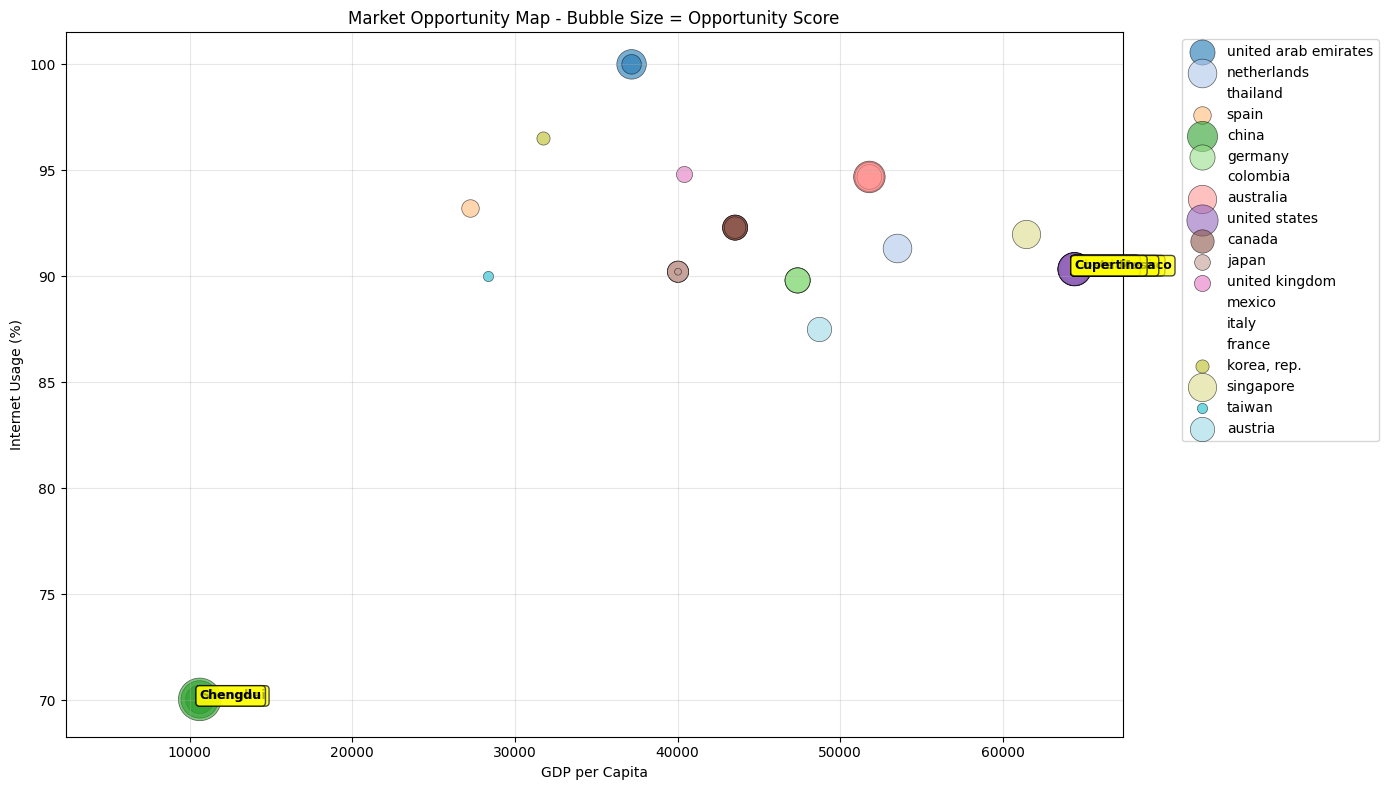

In [18]:
class MarketOpportunityScorer:
    """
    Score potential markets based on multiple factors
    """

    def __init__(self):
        self.feature_weights = {
            'gdp_per_capita': 0.25,
            'internet_usage_pct': 0.20,
            'market_size_potential': 0.20,
            'competitive_landscape': 0.15,
            'cultural_fit': 0.10,
            'logistics_score': 0.10
        }

    def calculate_market_scores(self, city_data):
        """
        Calculate opportunity scores for each city
        """
        # Normalize key metrics
        scaler = StandardScaler()

        metrics = ['gdp_per_capita_first', 'internet_usage_pct_first', 'total_revenue', 'store_count', 'Population_first']  # Corrected: Population and other column names
        normalized = scaler.fit_transform(city_data[metrics].fillna(0))

        city_data['gdp_score'] = normalized[:, 0]
        city_data['internet_score'] = normalized[:, 1]
        city_data['revenue_score'] = normalized[:, 2]
        city_data['presence_score'] = normalized[:, 3]
        city_data['population_score'] = normalized[:, 4]  # Corrected: Population score

        # Market size potential (inverse of current presence * economic indicators * population)
        city_data['market_potential'] = (
            (1 - city_data['presence_score'].clip(0, 0.95)) *
            city_data['gdp_score'] *
            city_data['internet_score'] *
            city_data['population_score']  # Corrected: Include population in market potential
        )

        # Competitive landscape (less stores = more opportunity)
        city_data['competitive_score'] = 1 - city_data['presence_score'].clip(0, 1)

        # Overall opportunity score
        city_data['opportunity_score'] = (
            0.3 * city_data['gdp_score'] +
            0.2 * city_data['internet_score'] +
            0.3 * city_data['market_potential'] +
            0.2 * city_data['competitive_score']
        )

        # Rank opportunities
        city_data['opportunity_rank'] = city_data['opportunity_score'].rank(ascending=False)

        return city_data

    def identify_expansion_targets(self, city_data, min_score=0.5, max_existing_stores=2):
        """
        Identify top cities for expansion
        """
        expansion_targets = city_data[
            (city_data['opportunity_score'] > city_data['opportunity_score'].quantile(min_score)) &
            (city_data['store_count'] <= max_existing_stores)
        ].sort_values('opportunity_score', ascending=False)

        return expansion_targets[['city', 'country_norm_mapped', 'store_count',
                                   'gdp_per_capita_first', 'internet_usage_pct_first', 'Population_first',  # Corrected: Population and other column names
                                   'opportunity_score', 'opportunity_rank']]

    def visualize_opportunity_map(self, city_data):
        """
        Create opportunity bubble chart
        """
        plt.figure(figsize=(14, 8))

        # Size bubble by opportunity score
        sizes = (city_data['opportunity_score'] * 1000).clip(lower=0) # Ensure sizes are non-negative

        # Color by region/country
        countries = city_data['country_norm_mapped'].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(countries)))
        color_map = dict(zip(countries, colors))

        for country in countries:
            mask = city_data['country_norm_mapped'] == country
            # Only plot if there are data points for this country
            if not city_data.loc[mask].empty:
                plt.scatter(
                    city_data.loc[mask, 'gdp_per_capita_first'], # Corrected: gdp_per_capita column name
                    city_data.loc[mask, 'internet_usage_pct_first'], # Corrected: internet_usage_pct column name
                    s=sizes[mask],
                    c=[color_map[country]],
                    alpha=0.6,
                    label=country,
                    edgecolors='black',
                    linewidth=0.5
                )

        # Highlight top opportunities
        top_opportunities = city_data.nlargest(10, 'opportunity_score')
        for _, row in top_opportunities.iterrows():
            plt.annotate(
                row['city'],
                (row['gdp_per_capita_first'], row['internet_usage_pct_first']), # Corrected: gdp_per_capita and internet_usage_pct column names
                fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7)
            )

        plt.xlabel('GDP per Capita')
        plt.ylabel('Internet Usage (%)')
        plt.title('Market Opportunity Map - Bubble Size = Opportunity Score')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Score markets
scorer = MarketOpportunityScorer()
city_data = scorer.calculate_market_scores(city_data)

# Identify expansion targets
expansion_targets = scorer.identify_expansion_targets(city_data, min_score=0.7, max_existing_stores=1)
print("\nTop 20 Expansion Targets:")
print(expansion_targets.head(20))

# Visualize opportunity map
scorer.visualize_opportunity_map(city_data)

3. Hierarchical Bayesian Model for Market Prediction

Output()

ERROR:pymc.stats.convergence:There were 17 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


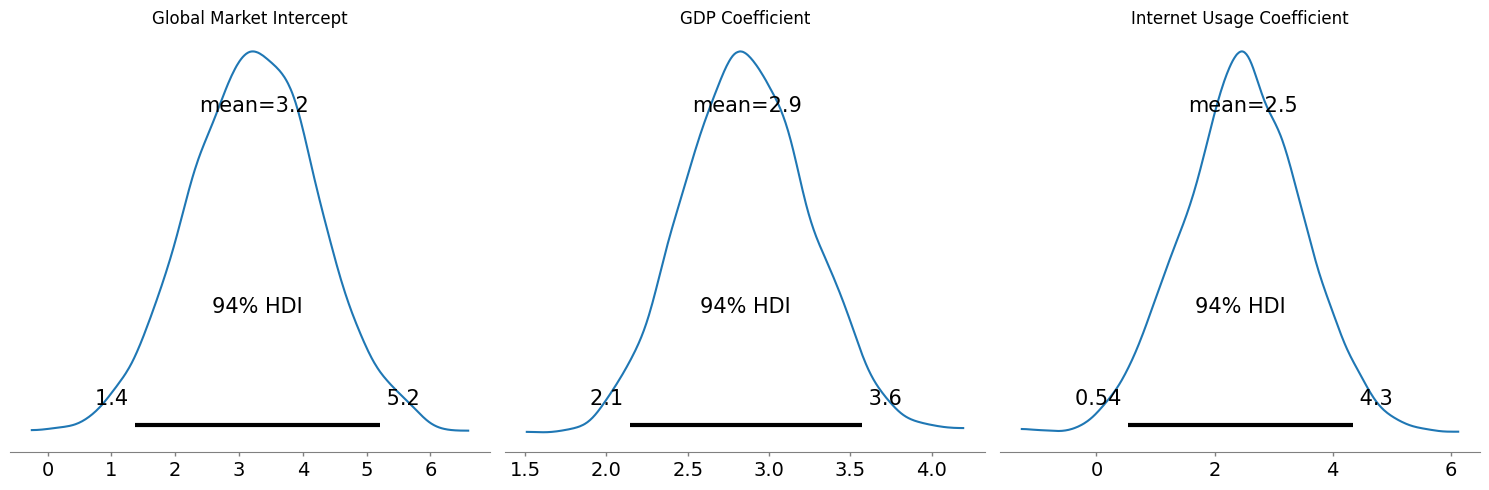

AttributeError: 'tuple' object has no attribute 'values'

In [19]:
import pymc as pm
import arviz as az
import numpy as np

class HierarchicalMarketModel:
    """
    Cluster cities based on market characteristics to identify similar markets
    """

    def __init__(self):
        self.model = None
        self.trace = None

    def build_model(self, city_data):
        """
        Build hierarchical model with country-level effects
        """
        # Prepare data
        countries = city_data['country_norm_mapped'].astype('category')
        country_names = countries.cat.categories.tolist()
        country_idx = countries.cat.codes.values
        n_countries = len(country_names)

        # Features
        gdp = city_data['gdp_per_capita_first'].values / 10000  # Scale
        internet = city_data['internet_usage_pct_first'].values / 100

        # Target (log revenue)
        revenue = np.log1p(city_data['total_revenue'].values)

        with pm.Model(coords={"country": country_names}) as hierarchical_model:
            # Country-level hyperpriors
            mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=1)
            sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)
            mu_beta = pm.Normal('mu_beta', mu=0, sigma=1, shape=2)
            sigma_beta = pm.HalfNormal('sigma_beta', sigma=1, shape=2)

            # Country-level intercepts
            alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, dims="country")

            # Country-level slopes
            beta_gdp = pm.Normal('beta_gdp', mu=mu_beta[0], sigma=sigma_beta[0], dims="country")
            beta_internet = pm.Normal('beta_internet', mu=mu_beta[1], sigma=sigma_beta[1], dims="country")

            # City-level linear predictor
            mu_ = alpha[country_idx] + \
                  beta_gdp[country_idx] * gdp + \
                  beta_internet[country_idx] * internet

            # Likelihood
            sigma = pm.HalfNormal('sigma', sigma=1)
            revenue_obs = pm.Normal('revenue_obs', mu=mu_, sigma=sigma, observed=revenue)

            self.model = hierarchical_model

        return self.model

    def fit_model(self, draws=2000, tune=1000, target_accept=0.8):
        """
        Fit the hierarchical model using MCMC
        """
        with self.model:
            self.trace = pm.sample(draws=draws, tune=tune, return_inferencedata=True, target_accept=target_accept)

        return self.trace

    def predict_new_market(self, gdp, internet, country_name=None):
        """
        Predict revenue for a new market incorporating posterior uncertainty.
        """
        gdp_scaled = gdp / 10000
        internet_scaled = internet / 100

        with self.model:
            # Get posterior samples for coefficients
            alpha_samples = self.trace.posterior["alpha"].values
            beta_gdp_samples = self.trace.posterior["beta_gdp"].values
            beta_internet_samples = self.trace.posterior["beta_internet"].values
            sigma_samples = self.trace.posterior["sigma"].values

            # If country name is provided and exists in the model's coords, use its specific samples
            if country_name and country_name in self.model.coords["country"].values:
                country_idx_pred = list(self.model.coords["country"].values).index(country_name)
                alpha_pred_samples = alpha_samples[:, :, country_idx_pred].flatten()
                beta_gdp_pred_samples = beta_gdp_samples[:, :, country_idx_pred].flatten()
                beta_internet_pred_samples = beta_internet_samples[:, :, country_idx_pred].flatten()
            else:
                # For new/unseen countries, use global hyperprior means (mu_alpha, mu_beta)
                alpha_pred_samples = self.trace.posterior["mu_alpha"].values.flatten()
                beta_gdp_pred_samples = self.trace.posterior["mu_beta"].values[:, :, 0].flatten()
                beta_internet_pred_samples = self.trace.posterior["mu_beta"].values[:, :, 1].flatten()

            # Calculate mu (log_revenue mean) for each posterior sample
            mu_pred_samples = alpha_pred_samples + \
                              beta_gdp_pred_samples * gdp_scaled + \
                              beta_internet_pred_samples * internet_scaled

            # Sample from the likelihood for posterior predictive
            rng = np.random.default_rng(42) # For reproducibility
            revenue_pred_log = pm.Normal.dist(mu=mu_pred_samples, sigma=sigma_samples.flatten()).random(rng=rng)
            revenue_pred = np.expm1(revenue_pred_log)

            return {
                'mean_revenue': np.mean(revenue_pred),
                'median_revenue': np.median(revenue_pred),
                'lower_bound': np.percentile(revenue_pred, 2.5),
                'upper_bound': np.percentile(revenue_pred, 97.5)
            }

    def plot_country_effects(self):
        """
        Visualize country-level effects
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Alpha (intercept) distribution
        az.plot_posterior(self.trace, var_names=['mu_alpha'], ax=axes[0])
        axes[0].set_title('Global Market Intercept')

        # Beta GDP distribution
        az.plot_posterior(self.trace, var_names=['mu_beta'],
                          coords={'mu_beta_dim_0': 0}, ax=axes[1]) # Changed dim name for PyMCv5 compatibility
        axes[1].set_title('GDP Coefficient')

        # Beta Internet distribution
        az.plot_posterior(self.trace, var_names=['mu_beta'],
                          coords={'mu_beta_dim_0': 1}, ax=axes[2]) # Changed dim name for PyMCv5 compatibility
        axes[2].set_title('Internet Usage Coefficient')

        plt.tight_layout()
        plt.show()

# Fit hierarchical model
hierarchical_model = HierarchicalMarketModel()
hierarchical_model.build_model(city_data)
hierarchical_model.fit_model(draws=2000, tune=1000, target_accept=0.99)  # Increased draws, tune, and target_accept

# Plot country effects
hierarchical_model.plot_country_effects()

# Predict for a potential new market (example: predict for 'united states' or a generic new market)
# If country_name is None, it uses the global hyperpriors
new_market_pred = hierarchical_model.predict_new_market(
    gdp=25000,
    internet=85,
    country_name='united states' # Example: provide a country name if you want country-specific prediction
)
print("\nNew Market Revenue Prediction:")
print(f"Mean: ${new_market_pred['mean_revenue']:,.0f}")
print(f"95% CI: [${new_market_pred['lower_bound']:,.0f}, ${new_market_pred['upper_bound']:,.0f}]")

4. Transfer Learning for Market Insights

Mature markets: 9
Emerging markets: 38

Available columns in city_data:
['city', 'country_norm_mapped', 'total_revenue', 'avg_transaction_value', 'transaction_count', 'total_units_sold', 'store_count', 'product_variety', 'gdp_per_capita_first', 'internet_usage_pct_first', 'exchange_rate_first', 'inflation_rate_first', 'price_realistic_mean', 'Population_first', 'revenue_per_store', 'units_per_transaction', 'market_maturity', 'kmeans_cluster', 'gmm_cluster', 'gmm_probability', 'pca_1', 'pca_2', 'gdp_score', 'internet_score', 'revenue_score', 'presence_score', 'population_score', 'market_potential', 'competitive_score', 'opportunity_score', 'opportunity_rank']
Train R²: 0.968
Test R²: 0.918

Feature Importances:
                    feature  importance
0      gdp_per_capita_first    0.242889
4     units_per_transaction    0.220429
3     avg_transaction_value    0.192327
5          Population_first    0.185659
1  internet_usage_pct_first    0.158697
2           product_variety    0.000000


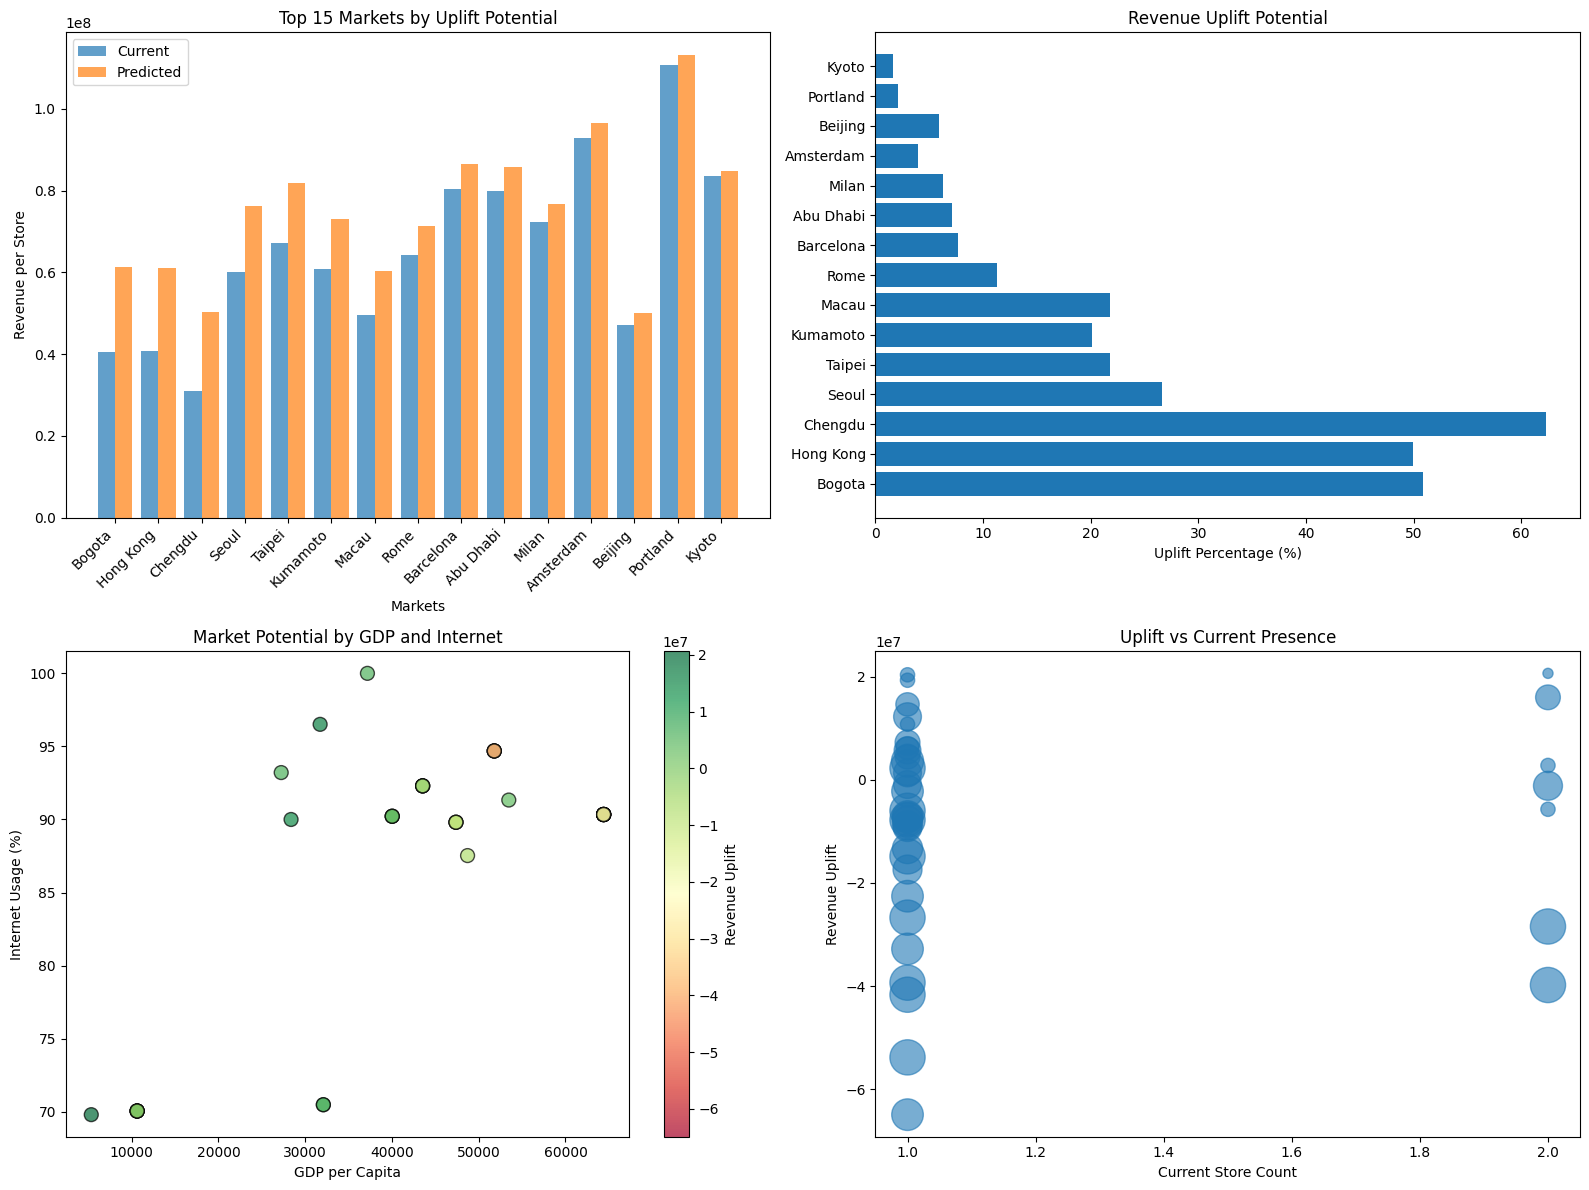


Top 10 Emerging Market Opportunities:
         city   country_norm_mapped  store_count  Population_first  \
6      Bogota              colombia            2           8050000   
20  Hong Kong                 china            1           7330000   
12    Chengdu                 china            1          16500000   
39      Seoul           korea, rep.            2           9650000   
43     Taipei                taiwan            1           2640000   
22   Kumamoto                 japan            1            733000   
26      Macau                 china            1            685000   
37       Rome                 italy            1           2860000   
3   Barcelona                 spain            1           1620000   
0   Abu Dhabi  united arab emirates            1           1590000   

    current_revenue_per_store  predicted_revenue_per_store  revenue_uplift  \
6                4.063112e+07                 6.128337e+07    2.065225e+07   
20               4.079665e+07     

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

class MarketTransferLearning:
    """
    Apply insights from mature markets to emerging markets
    """

    def __init__(self):
        self.model = RandomForestRegressor(n_estimators=100, random_state=42)
        self.mature_markets = None
        self.emerging_markets = None

    def split_markets(self, city_data, threshold=3):
        """
        Split markets into mature (source) and emerging (target)
        """
        self.mature_markets = city_data[city_data['store_count'] >= threshold].copy()
        self.emerging_markets = city_data[city_data['store_count'] < threshold].copy()

        print(f"Mature markets: {len(self.mature_markets)}")
        print(f"Emerging markets: {len(self.emerging_markets)}")

        return self.mature_markets, self.emerging_markets

    def train_on_mature_markets(self, features, target='revenue_per_store'):
        """
        Train model on mature markets
        """
        X = self.mature_markets[features]
        y = self.mature_markets[target]

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Train model
        self.model.fit(X_train, y_train)

        # Evaluate
        train_score = self.model.score(X_train, y_train)
        test_score = self.model.score(X_test, y_test)

        print(f"Train R²: {train_score:.3f}")
        print(f"Test R²: {test_score:.3f}")

        # Feature importance
        importance = pd.DataFrame({
            'feature': features,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        print("\nFeature Importances:")
        print(importance)

        return importance

    def predict_emerging_markets(self, features):
        """
        Predict potential for emerging markets
        """
        X_emerging = self.emerging_markets[features]

        # Predict
        self.emerging_markets['predicted_revenue_per_store'] = self.model.predict(X_emerging)

        # Calculate uplift potential
        self.emerging_markets['current_revenue_per_store'] = self.emerging_markets['revenue_per_store']
        self.emerging_markets['revenue_uplift'] = (
            self.emerging_markets['predicted_revenue_per_store'] -
            self.emerging_markets['current_revenue_per_store']
        )
        self.emerging_markets['uplift_percentage'] = (
            self.emerging_markets['revenue_uplift'] /
            self.emerging_markets['current_revenue_per_store'] * 100
        )

        return self.emerging_markets.sort_values('revenue_uplift', ascending=False)

    def visualize_transfer_insights(self, top_n=20):
        """
        Visualize transfer learning insights
        """
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Current vs Predicted
        top_markets = self.emerging_markets.nlargest(top_n, 'revenue_uplift')

        x = range(len(top_markets))
        axes[0, 0].bar(x, top_markets['current_revenue_per_store'], width=0.4, label='Current', alpha=0.7)
        axes[0, 0].bar([i + 0.4 for i in x], top_markets['predicted_revenue_per_store'],
                       width=0.4, label='Predicted', alpha=0.7)
        axes[0, 0].set_xlabel('Markets')
        axes[0, 0].set_ylabel('Revenue per Store')
        axes[0, 0].set_title(f'Top {top_n} Markets by Uplift Potential')
        axes[0, 0].set_xticks([i + 0.2 for i in x])
        axes[0, 0].set_xticklabels(top_markets['city'].str[:10], rotation=45, ha='right')
        axes[0, 0].legend()

        # Uplift percentage
        axes[0, 1].barh(top_markets['city'].str[:15], top_markets['uplift_percentage'])
        axes[0, 1].set_xlabel('Uplift Percentage (%)')
        axes[0, 1].set_title('Revenue Uplift Potential')

        # GDP vs Internet with potential
        scatter = axes[1, 0].scatter(
            self.emerging_markets['gdp_per_capita_first'], # Corrected column name
            self.emerging_markets['internet_usage_pct_first'], # Corrected column name
            c=self.emerging_markets['revenue_uplift'],
            s=100,
            cmap='RdYlGn',
            alpha=0.7,
            edgecolors='black'
        )
        axes[1, 0].set_xlabel('GDP per Capita')
        axes[1, 0].set_ylabel('Internet Usage (%)')
        axes[1, 0].set_title('Market Potential by GDP and Internet')
        plt.colorbar(scatter, ax=axes[1, 0], label='Revenue Uplift')

        # Store count vs potential
        axes[1, 1].scatter(
            self.emerging_markets['store_count'],
            self.emerging_markets['revenue_uplift'],
            s=self.emerging_markets['gdp_per_capita_first'] / 100, # Corrected column name
            alpha=0.6
        )
        axes[1, 1].set_xlabel('Current Store Count')
        axes[1, 1].set_ylabel('Revenue Uplift')
        axes[1, 1].set_title('Uplift vs Current Presence')

        plt.tight_layout()
        plt.show()

# Apply transfer learning
transfer = MarketTransferLearning()
mature, emerging = transfer.split_markets(city_data, threshold=3)

# FIXED: Use correct column names from your city_data
# Check what columns are actually available
print("\nAvailable columns in city_data:")
print(city_data.columns.tolist())

# Update features to match actual column names
features = ['gdp_per_capita_first', 'internet_usage_pct_first', 'product_variety',
            'avg_transaction_value', 'units_per_transaction', 'Population_first'] # Corrected column names

# Train on mature markets
feature_importance = transfer.train_on_mature_markets(features)

# Predict for emerging markets
emerging_with_predictions = transfer.predict_emerging_markets(features)

# Visualize insights
transfer.visualize_transfer_insights(top_n=15)

# Top emerging market opportunities
print("\nTop 10 Emerging Market Opportunities:")
print(emerging_with_predictions[['city', 'country_norm_mapped', 'store_count', 'Population_first', # Corrected column name
                                   'current_revenue_per_store', 'predicted_revenue_per_store',
                                   'revenue_uplift', 'uplift_percentage']].head(10))

5. Final Recommendations Dashboard

In [21]:
def generate_expansion_recommendations(city_data, emerging_predictions, expansion_targets):
    """
    Generate final market expansion recommendations
    """

    recommendations = []

    # Combine insights
    for _, row in expansion_targets.head(30).iterrows():
        city = row['city']
        country = row['country_norm_mapped']

        # Find in emerging predictions
        emerging_row = emerging_predictions[emerging_predictions['city'] == city]

        if len(emerging_row) > 0:
            uplift = emerging_row['revenue_uplift'].values[0]
            predicted = emerging_row['predicted_revenue_per_store'].values[0]
        else:
            uplift = 0
            predicted = row['revenue_per_store']

        # Generate recommendation
        rec = {
            'city': city,
            'country': country,
            'current_stores': row['store_count'],
            'gdp_per_capita': row['gdp_per_capita_first'], # Corrected: using _first suffix
            'internet_usage': row['internet_usage_pct_first'], # Corrected: using _first suffix
            'population': row['Population_first'],  # Corrected: using _first suffix
            'opportunity_score': row['opportunity_score'],
            'predicted_revenue_per_store': predicted,
            'revenue_uplift': uplift if uplift > 0 else 0,
            'recommended_stores': min(5, max(1, int(row['opportunity_score'] * 5))),
            'priority': 'High' if row['opportunity_score'] > 0.8 else 'Medium' if row['opportunity_score'] > 0.6 else 'Low'
        }
        recommendations.append(rec)

    rec_df = pd.DataFrame(recommendations).sort_values('opportunity_score', ascending=False)

    # Summary statistics
    print("=" * 80)
    print("MARKET EXPANSION RECOMMENDATIONS SUMMARY")
    print("=" * 80)
    print(f"\nTotal potential markets analyzed: {len(rec_df)}")
    print(f"High priority markets: {len(rec_df[rec_df['priority'] == 'High'])}")
    print(f"Medium priority markets: {len(rec_df[rec_df['priority'] == 'Medium'])}")
    print(f"Low priority markets: {len(rec_df[rec_df['priority'] == 'Low'])}")

    print("\n" + "=" * 80)
    print("TOP 20 RECOMMENDED MARKETS FOR EXPANSION")
    print("=" * 80)

    display_cols = ['city', 'country', 'current_stores', 'gdp_per_capita',
                    'internet_usage', 'population', 'opportunity_score',  # ADDED: population to display
                    'predicted_revenue_per_store', 'recommended_stores', 'priority']

    # Make sure to use the correct column names for display_cols from the newly created rec_df
    # The names in rec_df are 'gdp_per_capita', 'internet_usage', 'population' as defined in the rec dictionary above
    # So the display_cols list is actually fine as is AFTER the fix in the 'rec' dictionary.

    return rec_df[display_cols].head(20)

# Generate final recommendations
final_recommendations = generate_expansion_recommendations(
    city_data,
    emerging_with_predictions,
    expansion_targets
)

print("\n")
print(final_recommendations.to_string(index=False))

# Save results
final_recommendations.to_csv('market_expansion_recommendations.csv', index=False)
print("\nRecommendations saved to 'market_expansion_recommendations.csv'")

MARKET EXPANSION RECOMMENDATIONS SUMMARY

Total potential markets analyzed: 11
High priority markets: 0
Medium priority markets: 1
Low priority markets: 10

TOP 20 RECOMMENDED MARKETS FOR EXPANSION


         city       country  current_stores  gdp_per_capita  internet_usage  population  opportunity_score  predicted_revenue_per_store  recommended_stores priority
      Chengdu         china               1        10627.46           70.05    16500000           0.724940                 5.029656e+07                   3   Medium
     Brooklyn united states               1        64401.51           90.34     2560000           0.584347                 1.130148e+08                   2      Low
 Philadelphia united states               1        64401.51           90.34     1550000           0.569066                 1.130148e+08                   2      Low
San Francisco united states               1        64401.51           90.34      808000           0.557839                 1.130148e+08     